In [1]:
import pandas as pd
import numpy as np
# from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('housing.csv')

In [3]:
df['income_cat'] = pd.cut(df['median_income'], bins=[0,1.5,3.0,4.5,6.0, np.inf],labels=[1,2,3,4,5])

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df,df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]
    

In [8]:
for sett in (strat_train_set,strat_test_set):
    sett.drop('income_cat',axis=1, inplace=True)

In [10]:
df = strat_train_set.copy()

In [13]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN


<Axes: xlabel='latitude', ylabel='longitude'>

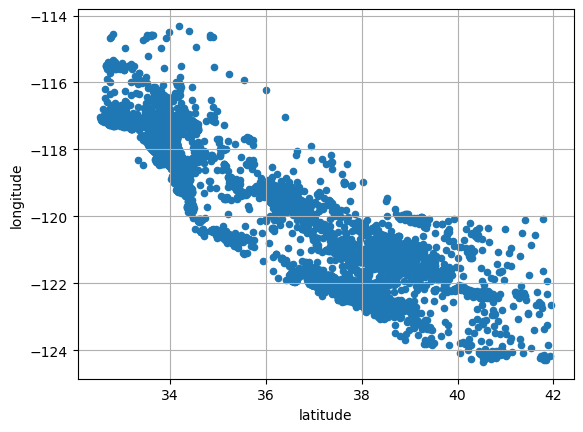

In [16]:
df.plot(kind='scatter', x = "latitude", y = "longitude", grid=True)

<Axes: xlabel='latitude', ylabel='longitude'>

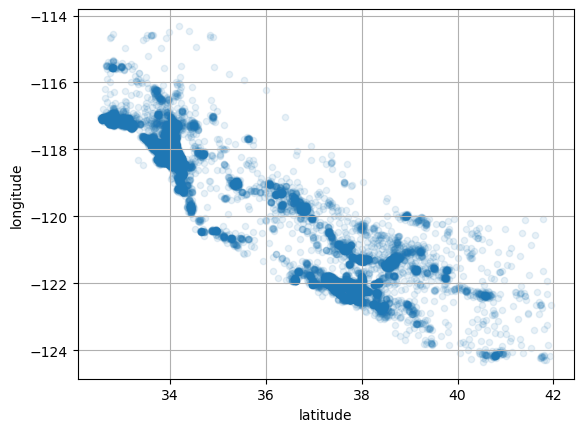

In [17]:
df.plot(kind='scatter', x = "latitude", y = "longitude", grid=True, alpha=0.1)

<Axes: xlabel='latitude', ylabel='longitude'>

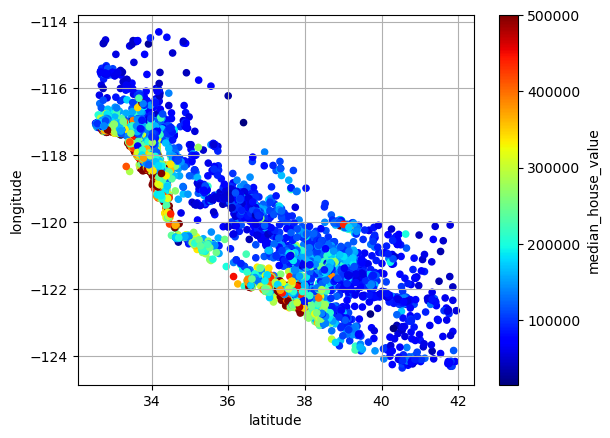

In [18]:
df.plot(kind='scatter', x = "latitude", y = "longitude", grid=True, cmap='jet', c='median_house_value')

In [19]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [20]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [ ]:
imputer.statistics_
# array([-118.51 ,  34.26 ,  29. , 2125. , 434. , 1167. , 408. , 3.5385])